# Telco Customer Churn Prediction

In [1]:
import json
import subprocess
import sys
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import xgboost
from scipy.stats import loguniform, randint, uniform
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay,
                             accuracy_score, average_precision_score, brier_score_loss, f1_score,
                             precision_recall_curve, precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import (RandomizedSearchCV, StratifiedKFold, cross_val_predict,
                                     cross_validate, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

pd.set_option("display.max_columns", 30)

SEED = 42
DATA_PATH = Path("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
MODEL_DIR = Path("models")

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = ["gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService", "MultipleLines",
            "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
            "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod"]

# Task 1: EDA & Preprocessing

In [2]:
df_raw = pd.read_csv(DATA_PATH)
print(df_raw.shape)
df_raw.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1.1 Data types and missing values

In [3]:
pd.DataFrame({"dtype": df_raw.dtypes.astype(str), "n_unique": df_raw.nunique(), "n_missing": df_raw.isna().sum()})

,dtype,n_unique,n_missing
customerID,str,7043,0
gender,str,2,0
SeniorCitizen,int64,2,0
Partner,str,2,0
Dependents,str,2,0
tenure,int64,73,0
PhoneService,str,2,0
MultipleLines,str,3,0
InternetService,str,3,0
OnlineSecurity,str,3,0


In [4]:
# TotalCharges came in as text - which values don't parse?
bad = pd.to_numeric(df_raw["TotalCharges"], errors="coerce").isna()
print(bad.sum(), "rows")
df_raw.loc[bad, ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

11 rows


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [5]:
# all of them are tenure 0, i.e. not billed yet -> real value is 0.
# convert to float here (no fitting involved), the 0-fill happens inside the pipeline
df = df_raw.copy()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(df["TotalCharges"].dtype, df["TotalCharges"].isna().sum())

float64 11


## 1.2 Class imbalance

Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


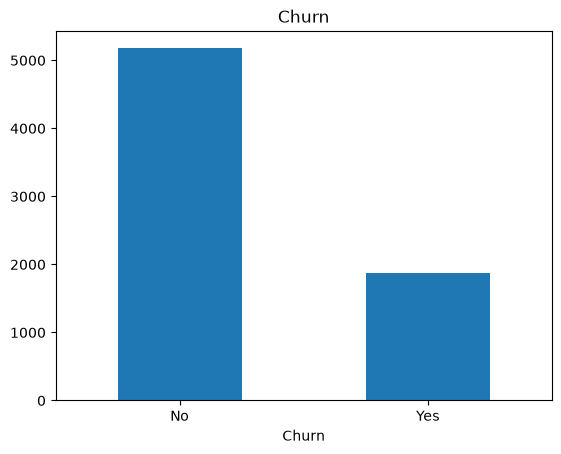

In [6]:
print(df["Churn"].value_counts(normalize=True).round(3))
df["Churn"].value_counts().plot.bar(rot=0, title="Churn")
plt.show()

## 1.3 Numeric features vs churn

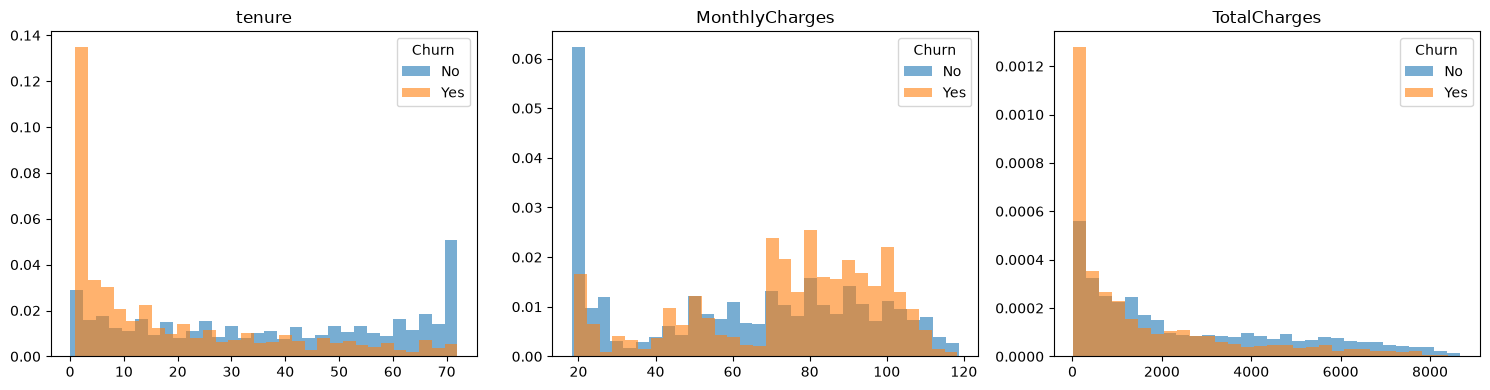

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,38.0,64.425,1683.60
Yes,10.0,79.650,703.55


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    for label, grp in df.groupby("Churn"):
        ax.hist(grp[col].dropna(), bins=30, alpha=0.6, density=True, label=label)
    ax.set_title(col)
    ax.legend(title="Churn")
plt.tight_layout()
plt.show()

df.groupby("Churn")[num_cols].median()

In [8]:
df[num_cols].corr().round(2)

,tenure,MonthlyCharges,TotalCharges
tenure,1.00,0.25,0.83
MonthlyCharges,0.25,1.00,0.65
TotalCharges,0.83,0.65,1.00


## 1.4 Categorical features vs churn

In [9]:
churn = df["Churn"].eq("Yes")
rates = {col: churn.groupby(df[col]).mean() for col in cat_cols}
spread = pd.Series({col: r.max() - r.min() for col, r in rates.items()}).sort_values(ascending=False)
spread.round(3)

Contract            0.399
InternetService     0.345
OnlineSecurity      0.344
TechSupport         0.342
OnlineBackup        0.325
DeviceProtection    0.317
PaymentMethod       0.300
StreamingMovies     0.263
StreamingTV         0.261
SeniorCitizen       0.181
PaperlessBilling    0.172
Dependents          0.158
Partner             0.133
MultipleLines       0.037
PhoneService        0.018
gender              0.008
dtype: float64

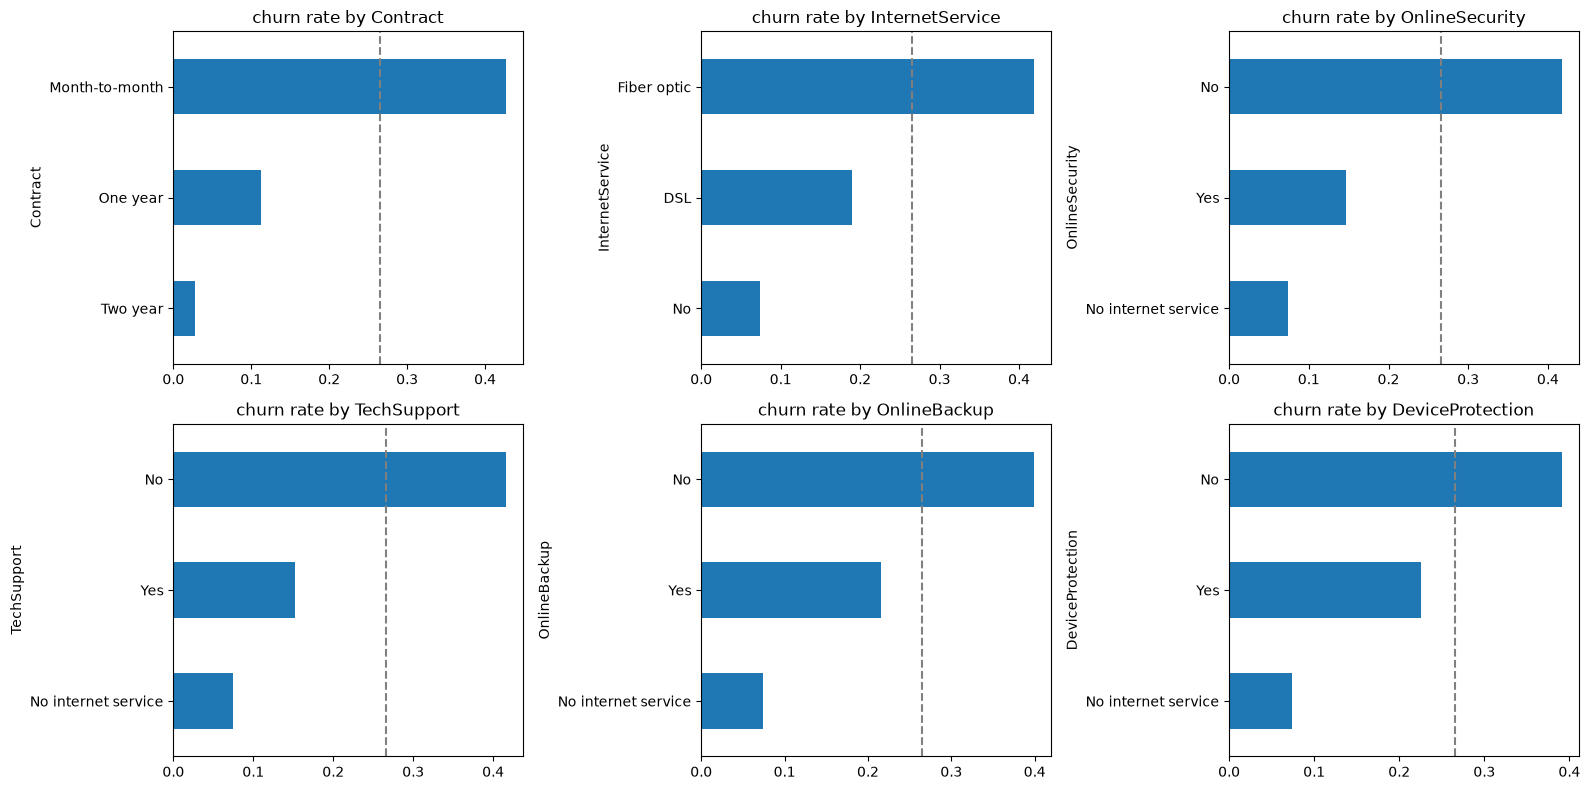

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, spread.index[:6]):
    rates[col].sort_values().plot.barh(ax=ax)
    ax.axvline(churn.mean(), ls="--", color="grey")
    ax.set_title(f"churn rate by {col}")
plt.tight_layout()
plt.show()

## 1.5 Preprocessing pipeline

In [11]:
def make_preprocessor():
    num = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
    total = Pipeline([("impute", SimpleImputer(strategy="constant", fill_value=0.0)),
                      ("scale", StandardScaler())])
    cat = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False))])
    return ColumnTransformer([
        ("num", num, ["tenure", "MonthlyCharges"]),
        ("total", total, ["TotalCharges"]),
        ("cat", cat, cat_cols),
    ], verbose_feature_names_out=False)


def make_pipeline(model):
    return Pipeline([("prep", make_preprocessor()), ("model", model)])


make_pipeline(LogisticRegression())

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('total', ...), ...]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}

# Task 2: Model Training & Evaluation

## 2.1 Train/test split

In [12]:
X = df.drop(columns=["customerID", "Churn"])
y = (df["Churn"] == "Yes").astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print(X_train.shape, X_test.shape, round(y_train.mean(), 3), round(y_test.mean(), 3))

(5634, 19) (1409, 19) 0.265 0.265


## 2.2 Models

In [13]:
# name: (estimator, search space, n_iter)
models = {
    "Dummy (majority class)": (DummyClassifier(strategy="most_frequent"), None, 0),
    "Logistic Regression": (LogisticRegression(max_iter=2000), {"C": loguniform(1e-3, 1e2)}, 15),
    "Random Forest": (
        RandomForestClassifier(n_estimators=400, random_state=SEED),
        {"max_depth": [6, 8, 12, None], "min_samples_leaf": randint(1, 20), "max_features": ["sqrt", 0.3, 0.5]},
        15,
    ),
    "XGBoost": (
        XGBClassifier(tree_method="hist", eval_metric="logloss", n_jobs=1, random_state=SEED),
        {
            "n_estimators": randint(100, 600),
            "learning_rate": loguniform(0.01, 0.2),
            "max_depth": randint(2, 7),
            "min_child_weight": randint(1, 10),
            "subsample": uniform(0.6, 0.4),
            "colsample_bytree": uniform(0.5, 0.5),
            "reg_lambda": loguniform(0.1, 10),
        },
        40,
    ),
}

## 2.3 Helpers

In [14]:
scoring = {"pr_auc": "average_precision", "roc_auc": "roc_auc"}


def best_threshold(model, X, y):
    # F1-optimal cutoff on out-of-fold predictions, so the test set isn't used
    proba = cross_val_predict(clone(model), X, y, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
    p, r, t = precision_recall_curve(y, proba)
    f1 = 2 * p * r / np.clip(p + r, 1e-12, None)
    return float(t[np.argmax(f1[:-1])])


def test_metrics(model, threshold):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {
        "roc_auc": roc_auc_score(y_test, proba),
        "pr_auc": average_precision_score(y_test, proba),
        "f1": f1_score(y_test, pred, zero_division=0),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred),
        "accuracy": accuracy_score(y_test, pred),
        "brier": brier_score_loss(y_test, proba),
    }

## 2.4 Train all models

In [15]:
results = {}
for name, (est, space, n_iter) in models.items():
    pipe = make_pipeline(est)
    if space:
        search = RandomizedSearchCV(pipe, {f"model__{k}": v for k, v in space.items()}, n_iter=n_iter,
                                    scoring=scoring, refit="pr_auc", cv=cv, n_jobs=-1, random_state=SEED)
        search.fit(X_train, y_train)
        model, i = search.best_estimator_, search.best_index_
        cv_scores = {m: (search.cv_results_[f"mean_test_{m}"][i], search.cv_results_[f"std_test_{m}"][i])
                     for m in scoring}
        params = {k.replace("model__", ""): v for k, v in search.best_params_.items()}
    else:
        scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
        cv_scores = {m: (scores[f"test_{m}"].mean(), scores[f"test_{m}"].std()) for m in scoring}
        model, params = pipe.fit(X_train, y_train), {}

    # no point tuning a threshold for the dummy, its scores are constant
    threshold = best_threshold(model, X_train, y_train) if space else 0.5
    results[name] = {"model": model, "params": params, "threshold": threshold, "cv": cv_scores,
                     "test": test_metrics(model, threshold)}
    print(f"{name:24s} CV PR-AUC {cv_scores['pr_auc'][0]:.3f} +/- {cv_scores['pr_auc'][1]:.3f}"
          f"  CV ROC-AUC {cv_scores['roc_auc'][0]:.3f}  threshold {threshold:.2f}")

# pick on CV score, not test
best_name = max((n for n in results if not n.startswith("Dummy")), key=lambda n: results[n]["cv"]["pr_auc"][0])
best = results[best_name]
print("\nbest:", best_name, {k: round(float(v), 4) if isinstance(v, float) else v for k, v in best["params"].items()})

Dummy (majority class)   CV PR-AUC 0.265 +/- 0.000  CV ROC-AUC 0.500  threshold 0.50


Logistic Regression      CV PR-AUC 0.662 +/- 0.020  CV ROC-AUC 0.846  threshold 0.33


Random Forest            CV PR-AUC 0.667 +/- 0.020  CV ROC-AUC 0.847  threshold 0.34


XGBoost                  CV PR-AUC 0.673 +/- 0.018  CV ROC-AUC 0.850  threshold 0.35

best: XGBoost {'colsample_bytree': 0.561, 'learning_rate': 0.0291, 'max_depth': 2, 'min_child_weight': 1, 'n_estimators': 476, 'reg_lambda': 1.9742, 'subsample': 0.6002}


## 2.5 Model comparison

In [16]:
summary = pd.DataFrame({
    name: {"cv_pr_auc": r["cv"]["pr_auc"][0], "cv_pr_auc_std": r["cv"]["pr_auc"][1],
           "cv_roc_auc": r["cv"]["roc_auc"][0], **{f"test_{k}": v for k, v in r["test"].items()},
           "threshold": r["threshold"]}
    for name, r in results.items()
}).T
summary.round(3)

,cv_pr_auc,cv_pr_auc_std,cv_roc_auc,test_roc_auc,test_pr_auc,test_f1,test_precision,test_recall,test_accuracy,test_brier,threshold
Dummy (majority class),0.265,0.000,0.500,0.500,0.265,0.000,0.000,0.000,0.735,0.265,0.500
Logistic Regression,0.662,0.020,0.846,0.842,0.634,0.617,0.539,0.722,0.762,0.138,0.328
Random Forest,0.667,0.020,0.847,0.845,0.656,0.630,0.556,0.727,0.774,0.136,0.341
XGBoost,0.673,0.018,0.850,0.848,0.666,0.636,0.563,0.733,0.778,0.135,0.349


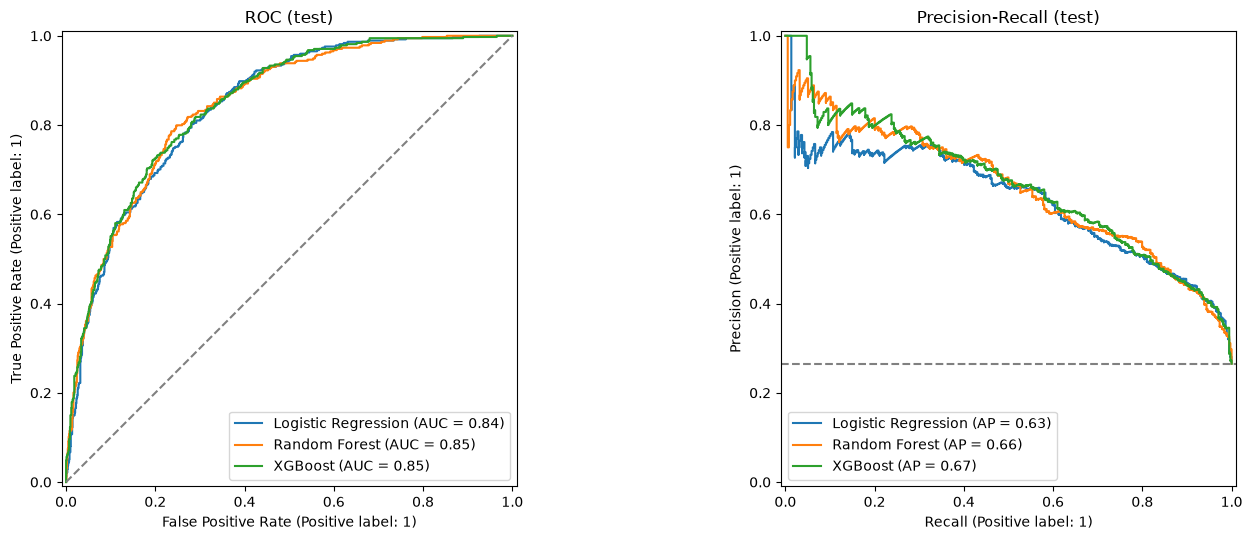

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))
for name, r in results.items():
    if name.startswith("Dummy"):
        continue
    RocCurveDisplay.from_estimator(r["model"], X_test, y_test, name=name, ax=ax1)
    PrecisionRecallDisplay.from_estimator(r["model"], X_test, y_test, name=name, ax=ax2)
ax1.plot([0, 1], [0, 1], ls="--", color="grey")
ax2.axhline(y_test.mean(), ls="--", color="grey")
ax1.set_title("ROC (test)")
ax2.set_title("Precision-Recall (test)")
plt.tight_layout()
plt.show()

## 2.6 Decision threshold

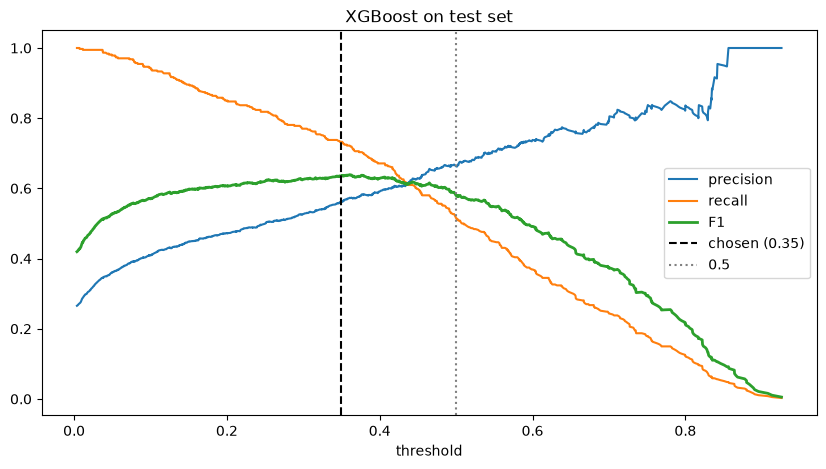

t=0.50: caught 192/374 churners, flagged 290, F1 0.578
t=0.35: caught 274/374 churners, flagged 487, F1 0.636


In [18]:
proba = best["model"].predict_proba(X_test)[:, 1]
p, r, t = precision_recall_curve(y_test, proba)
f1 = 2 * p * r / np.clip(p + r, 1e-12, None)

plt.figure(figsize=(10, 5))
plt.plot(t, p[:-1], label="precision")
plt.plot(t, r[:-1], label="recall")
plt.plot(t, f1[:-1], label="F1", lw=2)
plt.axvline(best["threshold"], color="black", ls="--", label=f"chosen ({best['threshold']:.2f})")
plt.axvline(0.5, color="grey", ls=":", label="0.5")
plt.xlabel("threshold")
plt.title(f"{best_name} on test set")
plt.legend()
plt.show()

for thr in (0.5, best["threshold"]):
    pred = (proba >= thr).astype(int)
    print(f"t={thr:.2f}: caught {pred[y_test == 1].sum()}/{y_test.sum()} churners, "
          f"flagged {pred.sum()}, F1 {f1_score(y_test, pred):.3f}")

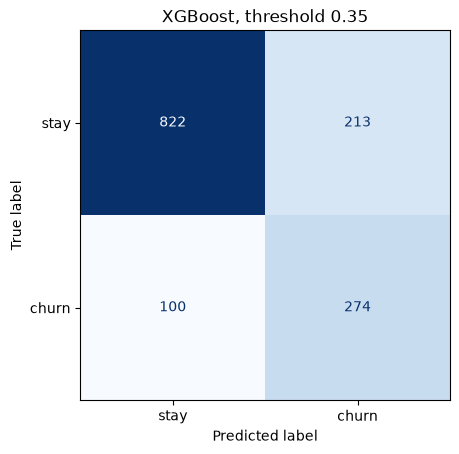

In [19]:
ConfusionMatrixDisplay.from_predictions(y_test, (proba >= best["threshold"]).astype(int),
                                        display_labels=["stay", "churn"], cmap="Blues", colorbar=False)
plt.title(f"{best_name}, threshold {best['threshold']:.2f}")
plt.show()

## 2.7 Feature importance

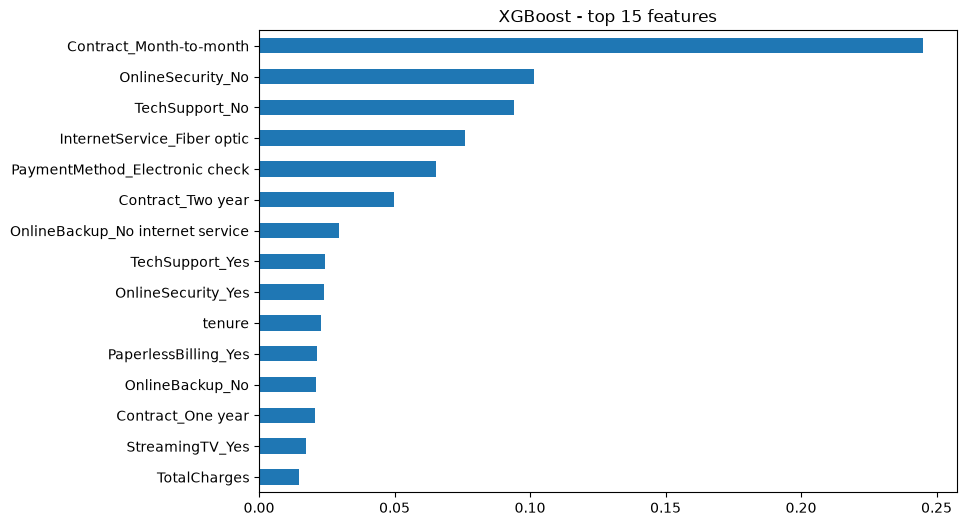

In [20]:
fitted = best["model"].named_steps["model"]
names = best["model"].named_steps["prep"].get_feature_names_out()
imp = pd.Series(fitted.feature_importances_ if hasattr(fitted, "feature_importances_") else fitted.coef_[0],
                index=names)
imp.reindex(imp.abs().sort_values().index)[-15:].plot.barh(figsize=(9, 6), title=f"{best_name} - top 15 features")
plt.show()

## 2.8 Accuracy vs dummy baseline

In [21]:
summary.loc[["Dummy (majority class)", best_name], ["test_accuracy", "test_recall", "test_f1", "test_pr_auc"]].round(3)

,test_accuracy,test_recall,test_f1,test_pr_auc
Dummy (majority class),0.735,0.000,0.000,0.265
XGBoost,0.778,0.733,0.636,0.666


# Task 3: Export & Inference

## 3.1 Save the model

In [22]:
MODEL_DIR.mkdir(exist_ok=True)
joblib.dump({
    "pipeline": best["model"],
    "threshold": best["threshold"],
    "metadata": {
        "model": best_name,
        "trained_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "params": best["params"],
        "test_metrics": best["test"],
        "sklearn": sklearn.__version__,
        "xgboost": xgboost.__version__,
    },
}, MODEL_DIR / "churn_model.joblib")

metrics = {name: {k: r[k] for k in ("params", "threshold", "cv", "test")} for name, r in results.items()}
(MODEL_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2, default=lambda o: o.item()))
list(MODEL_DIR.iterdir())

[WindowsPath('models/churn_model.joblib'), WindowsPath('models/metrics.json')]

## 3.2 predict.py

In [23]:
%%writefile predict.py
"""Score a single customer with the saved churn model.

    python predict.py samples/customer.json
    python predict.py - < samples/customer.json
"""
import argparse
import json
import sys
from pathlib import Path
from typing import Literal

import joblib
import pandas as pd
from pydantic import BaseModel, Field, field_validator

MODEL_PATH = Path(__file__).parent / "models" / "churn_model.joblib"

YesNo = Literal["Yes", "No"]
InternetAddon = Literal["Yes", "No", "No internet service"]


class Customer(BaseModel):
    customerID: str | None = None
    gender: Literal["Female", "Male"]
    SeniorCitizen: Literal[0, 1]
    Partner: YesNo
    Dependents: YesNo
    tenure: int = Field(ge=0)
    PhoneService: YesNo
    MultipleLines: Literal["Yes", "No", "No phone service"]
    InternetService: Literal["DSL", "Fiber optic", "No"]
    OnlineSecurity: InternetAddon
    OnlineBackup: InternetAddon
    DeviceProtection: InternetAddon
    TechSupport: InternetAddon
    StreamingTV: InternetAddon
    StreamingMovies: InternetAddon
    Contract: Literal["Month-to-month", "One year", "Two year"]
    PaperlessBilling: YesNo
    PaymentMethod: Literal["Electronic check", "Mailed check", "Bank transfer (automatic)",
                           "Credit card (automatic)"]
    MonthlyCharges: float = Field(ge=0)
    TotalCharges: float | None = Field(default=None, ge=0)

    @field_validator("TotalCharges", mode="before")
    @classmethod
    def blank_is_none(cls, v):
        # raw data has " " for customers that haven't been billed yet
        return None if isinstance(v, str) and not v.strip() else v


class ChurnModel:
    def __init__(self, path=MODEL_PATH):
        bundle = joblib.load(path)
        self.pipeline = bundle["pipeline"]
        self.threshold = bundle["threshold"]
        self.metadata = bundle["metadata"]

    def predict(self, data):
        customer = data if isinstance(data, Customer) else Customer.model_validate(data)
        row = pd.DataFrame([customer.model_dump()])
        row["TotalCharges"] = pd.to_numeric(row["TotalCharges"], errors="coerce")  # same as training
        proba = float(self.pipeline.predict_proba(row[self.pipeline.feature_names_in_])[0, 1])
        return {
            "customerID": customer.customerID,
            "churn_prediction": int(proba >= self.threshold),
            "churn_probability": round(proba, 4),
        }


if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("input", help="customer JSON file, or - for stdin")
    args = parser.parse_args()
    raw = sys.stdin.read() if args.input == "-" else Path(args.input).read_text()
    print(json.dumps(ChurnModel().predict(json.loads(raw)), indent=2))

Writing predict.py


In [24]:
out = subprocess.run([sys.executable, "predict.py", "samples/customer.json"], capture_output=True, text=True)
print(out.stdout or out.stderr)

{
  "customerID": "7590-VHVEG",
  "churn_prediction": 1,
  "churn_probability": 0.7093
}



In [25]:
import predict

sample = json.loads(Path("samples/customer.json").read_text())
model = predict.ChurnModel()
print(model.predict(sample))

try:
    model.predict({**sample, "Contract": "Weekly"})
except Exception as e:
    print(e)

{'customerID': '7590-VHVEG', 'churn_prediction': 1, 'churn_probability': 0.7093}
1 validation error for Customer
Contract
  Input should be 'Month-to-month', 'One year' or 'Two year' [type=literal_error, input_value='Weekly', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/literal_error


## 3.3 app.py (FastAPI)

In [26]:
%%writefile app.py
"""uvicorn app:app --port 8000"""
from fastapi import FastAPI

from predict import ChurnModel, Customer

app = FastAPI(title="Churn prediction")
model = ChurnModel()


@app.get("/health")
def health():
    return {"status": "ok", "model": model.metadata["model"], "trained_at": model.metadata["trained_at"]}


@app.post("/predict")
def predict(customer: Customer):
    return model.predict(customer)

Writing app.py


In [27]:
from fastapi.testclient import TestClient

import app

client = TestClient(app.app)
print(client.get("/health").json())
print(client.post("/predict", json=sample).json())
print(client.post("/predict", json={**sample, "Contract": "Weekly"}).status_code)

{'status': 'ok', 'model': 'XGBoost', 'trained_at': '2026-10-01T19:07:50+00:00'}
{'customerID': '7590-VHVEG', 'churn_prediction': 1, 'churn_probability': 0.7093}
422


## 3.4 Tests

In [28]:
%%writefile test_inference.py
import json
from pathlib import Path

import pytest
from fastapi.testclient import TestClient
from pydantic import ValidationError

from app import app
from predict import ChurnModel

SAMPLE = json.loads((Path(__file__).parent / "samples" / "customer.json").read_text())


@pytest.fixture(scope="module")
def model():
    return ChurnModel()


def test_sample(model):
    out = model.predict(SAMPLE)
    assert out["customerID"] == "7590-VHVEG"
    assert 0 <= out["churn_probability"] <= 1
    assert out["churn_prediction"] == int(out["churn_probability"] >= model.threshold)


def test_total_charges_string_or_number(model):
    assert model.predict(SAMPLE) == model.predict({**SAMPLE, "TotalCharges": 29.85})


def test_blank_total_charges(model):
    assert 0 <= model.predict({**SAMPLE, "tenure": 0, "TotalCharges": " "})["churn_probability"] <= 1


def test_risky_customer_scores_higher(model):
    risky = {**SAMPLE, "InternetService": "Fiber optic", "tenure": 2, "MonthlyCharges": 95.0,
             "TotalCharges": "190"}
    loyal = {**SAMPLE, "Contract": "Two year", "tenure": 60, "MonthlyCharges": 55.0,
             "TotalCharges": "3300", "PaymentMethod": "Credit card (automatic)"}
    assert model.predict(risky)["churn_probability"] > model.predict(loyal)["churn_probability"]


@pytest.mark.parametrize("field, value", [("Contract", "Weekly"), ("tenure", -1), ("MonthlyCharges", "abc")])
def test_bad_input(model, field, value):
    with pytest.raises(ValidationError):
        model.predict({**SAMPLE, field: value})


def test_api():
    client = TestClient(app)
    assert client.post("/predict", json=SAMPLE).status_code == 200
    assert client.post("/predict", json={**SAMPLE, "Contract": "Weekly"}).status_code == 422

Writing test_inference.py


In [29]:
out = subprocess.run([sys.executable, "-m", "pytest", "-q", "--color=no", "-p", "no:cacheprovider",
                      "test_inference.py"], capture_output=True, text=True)
print(out.stdout[-800:])

........                                                                 [100%]
8 passed in 1.99s

